### Part A - Scikit-learn Implementation

In [404]:
import pandas as pd

In [405]:
df = pd.read_csv("garments_worker_productivity.csv")
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [406]:
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   str    
 1   quarter                1197 non-null   str    
 2   department             1197 non-null   str    
 3   day                    1197 non-null   str    
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: float64(6), 

In [407]:
df.isnull().sum()

date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [408]:
df.duplicated().sum()

np.int64(0)

In [409]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


In [410]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
team,1197.0,6.426901,3.463963,1.000000,3.000000,6.000000,9.000000,12.000000
targeted_productivity,1197.0,0.729632,0.097891,0.070000,0.700000,0.750000,0.800000,0.800000
smv,1197.0,15.062172,10.943219,2.900000,3.940000,15.260000,24.260000,54.560000
wip,691.0,1190.465991,1837.455001,7.000000,774.500000,1039.000000,1252.500000,23122.000000
over_time,1197.0,4567.460317,3348.823563,0.000000,1440.000000,3960.000000,6960.000000,25920.000000
incentive,1197.0,38.210526,160.182643,0.000000,0.000000,0.000000,50.000000,3600.000000
idle_time,1197.0,0.730159,12.709757,0.000000,0.000000,0.000000,0.000000,300.000000
idle_men,1197.0,0.369256,3.268987,0.000000,0.000000,0.000000,0.000000,45.000000
no_of_style_change,1197.0,0.150376,0.427848,0.000000,0.000000,0.000000,0.000000,2.000000
no_of_workers,1197.0,34.609858,22.197687,2.000000,9.000000,34.000000,57.000000,89.000000


In [411]:
print(df["department"].value_counts())
print(df["quarter"].value_counts())
print(df["day"].value_counts())

department
sweing        691
finishing     257
finishing     249
Name: count, dtype: int64
quarter
Quarter1    360
Quarter2    335
Quarter4    248
Quarter3    210
Quarter5     44
Name: count, dtype: int64
day
Wednesday    208
Sunday       203
Tuesday      201
Thursday     199
Monday       199
Saturday     187
Name: count, dtype: int64


In [412]:
df['department'] = df['department'].str.strip()

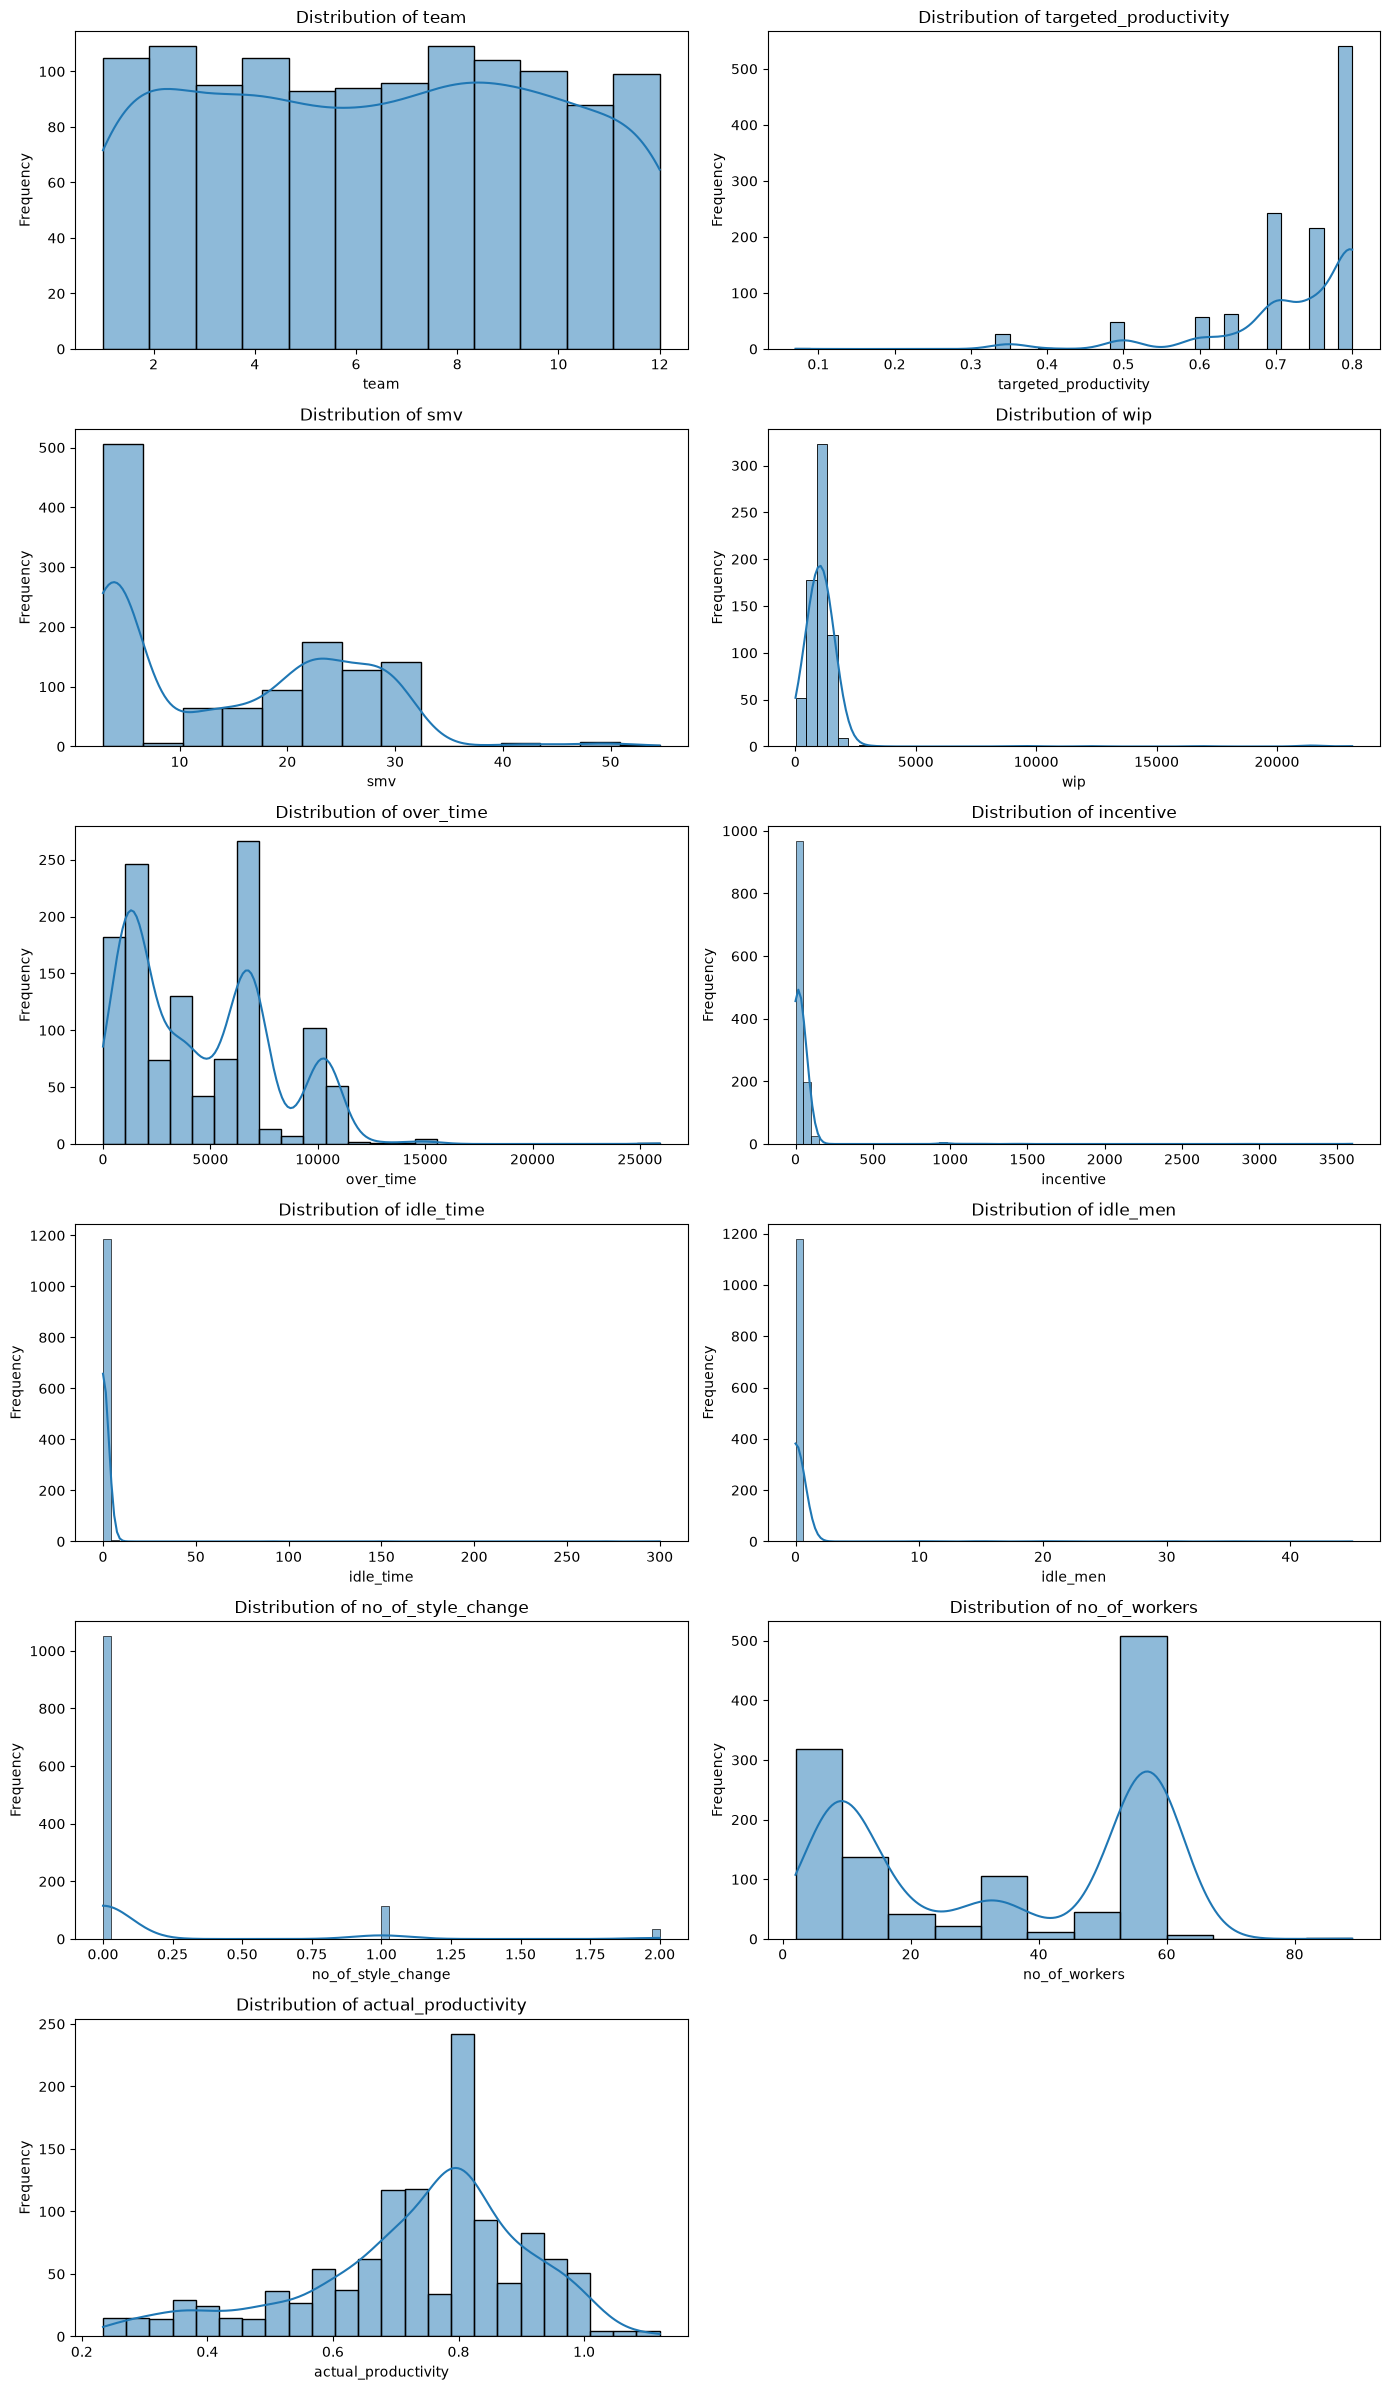

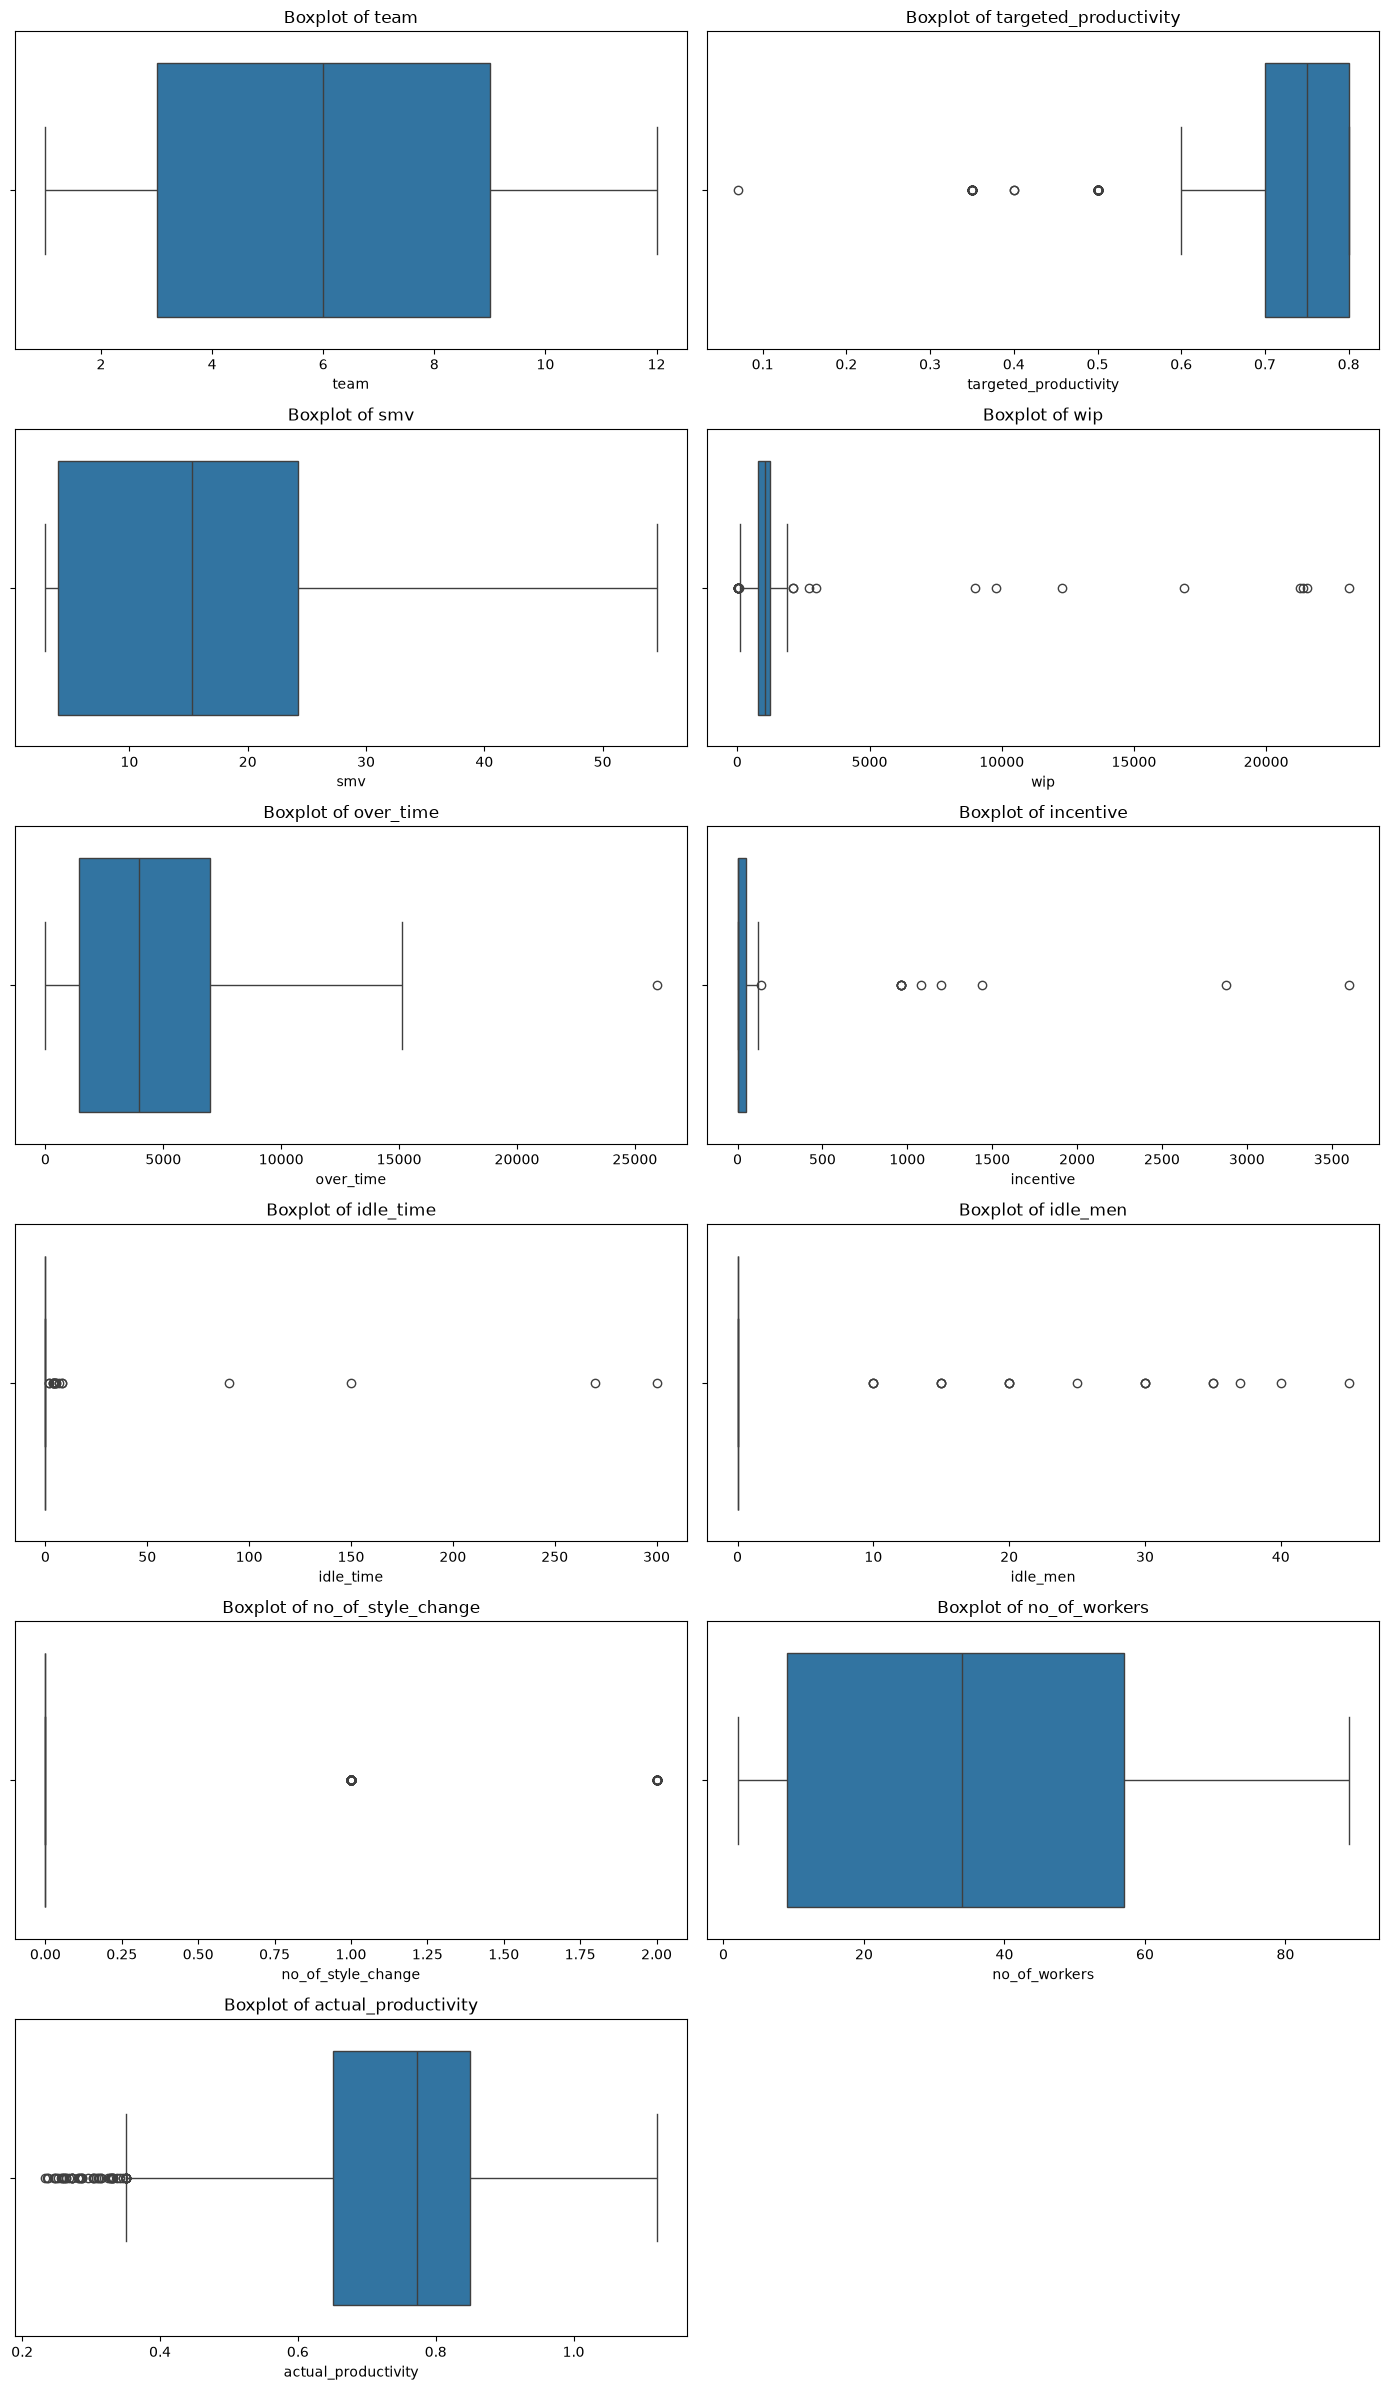

In [414]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = df.select_dtypes(include='number').columns

n = len(num_cols)
cols = 2
rows = (n + cols - 1) // cols

# Histograms
fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for i in range(n, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


# Boxplots
fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

for i in range(n, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [291]:
for col in df.columns:
    print(col, ":", df[col].nunique())

date : 59
quarter : 5
department : 2
day : 6
team : 12
targeted_productivity : 9
smv : 70
wip : 548
over_time : 143
incentive : 48
idle_time : 12
idle_men : 10
no_of_style_change : 3
no_of_workers : 61
actual_productivity : 879


In [292]:
df["actual_productivity"].describe()

count    1197.000000
mean        0.735091
std         0.174488
min         0.233705
25%         0.650307
50%         0.773333
75%         0.850253
max         1.120437
Name: actual_productivity, dtype: float64

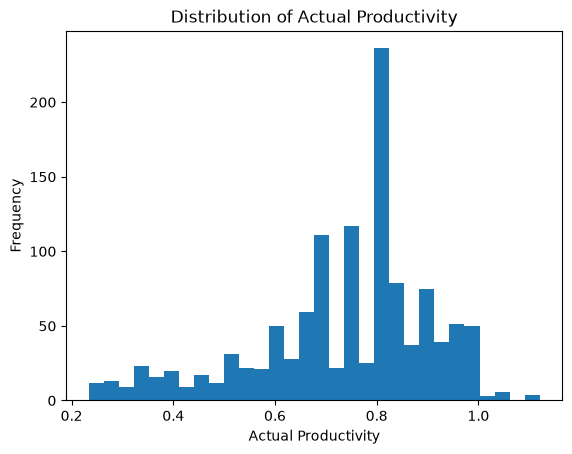

In [293]:
import matplotlib.pyplot as plt

plt.hist(df["actual_productivity"], bins=30)
plt.xlabel("Actual Productivity")
plt.ylabel("Frequency")
plt.title("Distribution of Actual Productivity")
plt.show()

In [294]:
df.select_dtypes(include="number").corr()["actual_productivity"].sort_values()

no_of_style_change      -0.207366
idle_men                -0.181734
team                    -0.148753
smv                     -0.122089
idle_time               -0.080851
no_of_workers           -0.057991
over_time               -0.054206
incentive                0.076538
wip                      0.131147
targeted_productivity    0.421594
actual_productivity      1.000000
Name: actual_productivity, dtype: float64

### Create the Classification Target

In [295]:
df["MeetsTarget"] = (
    df["actual_productivity"] >= df["targeted_productivity"]
).astype(int)

In [296]:
df["MeetsTarget"].value_counts()

MeetsTarget
1    875
0    322
Name: count, dtype: int64

In [297]:
df["MeetsTarget"].value_counts(normalize=True) * 100

MeetsTarget
1    73.099415
0    26.900585
Name: proportion, dtype: float64

In [298]:
#Regression
y_reg = df["actual_productivity"]

In [299]:

#Classification
y_cls = df["MeetsTarget"]

In [300]:
X_reg = df.drop(
    columns=["actual_productivity", "MeetsTarget"]
)

In [301]:
X_cls = df.drop(
    columns=["actual_productivity", "MeetsTarget"]
)

In [302]:
categorical_cols = X_reg.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X_reg.select_dtypes(
    exclude=["object"]
).columns.tolist()



C:\Users\Administrator\AppData\Local\Temp\ipykernel_15248\4116036944.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_reg.select_dtypes(


In [303]:
print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['date', 'quarter', 'department', 'day']
Numerical: ['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']


In [304]:
from sklearn.model_selection import train_test_split
reg_bins = pd.qcut(
    y_reg,
    q=5,
    labels=False,
    duplicates="drop"
)

combined_strata = (
    reg_bins.astype(str) + "_" +
    y_cls.astype(str)
)

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
    stratify=combined_strata
)

In [305]:
combined_strata.value_counts()

4_1    240
3_1    239
2_1    214
0_0    178
1_1    120
1_0    119
0_1     62
2_0     25
Name: count, dtype: int64

In [306]:
X = df.drop(columns=["actual_productivity", "MeetsTarget"])

y_reg = df["actual_productivity"]
y_cls = df["MeetsTarget"]

### split the data

In [307]:
X_train = X.loc[train_idx]
X_test = X.loc[test_idx]

y_reg_train = y_reg.loc[train_idx]
y_reg_test = y_reg.loc[test_idx]

y_cls_train = y_cls.loc[train_idx]
y_cls_test = y_cls.loc[test_idx]

In [308]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("Regression train:", y_reg_train.shape)
print("Regression test :", y_reg_test.shape)

print("Classification train:", y_cls_train.shape)
print("Classification test :", y_cls_test.shape)

X_train: (957, 14)
X_test : (240, 14)
Regression train: (957,)
Regression test : (240,)
Classification train: (957,)
Classification test : (240,)


In [309]:
print("Overall:")
print(y_cls.value_counts(normalize=True))

print("\nTrain:")
print(y_cls_train.value_counts(normalize=True))

print("\nTest:")
print(y_cls_test.value_counts(normalize=True))

Overall:
MeetsTarget
1    0.730994
0    0.269006
Name: proportion, dtype: float64

Train:
MeetsTarget
1    0.731452
0    0.268548
Name: proportion, dtype: float64

Test:
MeetsTarget
1    0.729167
0    0.270833
Name: proportion, dtype: float64


In [310]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [311]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [312]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [313]:
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [314]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [315]:
print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("Original X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_train shape: (957, 14)
Processed X_train shape: (957, 82)
Original X_test shape: (240, 14)
Processed X_test shape: (240, 82)


### train Linear Regression

In [316]:
from sklearn.linear_model import LinearRegression

In [317]:
linear_model = LinearRegression()
linear_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [318]:
import time

start_time = time.perf_counter()

linear_model.fit(
    X_train_processed,
    y_reg_train
)

linear_train_time = time.perf_counter() - start_time

In [319]:
start_time = time.perf_counter()

y_reg_pred = linear_model.predict(
    X_test_processed
)

linear_prediction_time = time.perf_counter() - start_time

In [320]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

In [321]:
rmse = mean_squared_error(
    y_reg_test,
    y_reg_pred
) ** 0.5

In [322]:
r2 = r2_score(
    y_reg_test,
    y_reg_pred
)

In [323]:

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)
print("Training time   :", linear_train_time)
print("Prediction time :", linear_prediction_time)

MAE : 0.10359823132302252
RMSE: 0.1437510388112509
R²  : 0.259662644427306
Training time   : 0.008428799999819603
Prediction time : 0.0007005000006756745


### Train the Logistic Regression

In [324]:
from sklearn.linear_model import LogisticRegression

In [325]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
logistic_model

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [326]:
start_time = time.perf_counter()

logistic_model.fit(
    X_train_processed,
    y_cls_train
)

logistic_train_time = time.perf_counter() - start_time

In [327]:
start_time = time.perf_counter()

y_cls_pred = logistic_model.predict(
    X_test_processed
)

logistic_prediction_time = time.perf_counter() - start_time

In [328]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(
    y_cls_test,
    y_cls_pred
)

In [329]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_cls_test,
    y_cls_pred
)

In [330]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_cls_test,
    y_cls_pred
)

In [331]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_cls_test,
    y_cls_pred
)

In [332]:

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("Training time   :", logistic_train_time)
print("Prediction time :", logistic_prediction_time)

Accuracy : 0.7416666666666667
Precision: 0.7652582159624414
Recall   : 0.9314285714285714
F1-score : 0.8402061855670103
Training time   : 0.014316500000859378
Prediction time : 0.0010297000007994939


In [333]:
    

regression_results = pd.DataFrame({
    "Model": ["Scikit-learn Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Training Time (s)": [linear_train_time],
    "Prediction Time (s)": [linear_prediction_time]
})

regression_results

,Model,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn Linear Regression,0.103598,0.143751,0.259663,0.008429,0.000701


In [334]:
classification_results = pd.DataFrame({
    "Model": ["Scikit-learn Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-Score": [f1],
    "Training Time (s)": [logistic_train_time],
    "Prediction Time (s)": [logistic_prediction_time]
})

classification_results

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Scikit-learn Logistic Regression,0.741667,0.765258,0.931429,0.840206,0.014317,0.00103


### Part B - From-Scratch Implementation

In [335]:
import numpy as np
import pandas as pd
import time

In [336]:
X = df.drop(
    columns=["actual_productivity", "MeetsTarget"]
)

y_reg = df["actual_productivity"]
y_cls = df["MeetsTarget"]

In [337]:
X_train = X.loc[train_idx].copy()
X_test = X.loc[test_idx].copy()

y_reg_train = y_reg.loc[train_idx].copy()
y_reg_test = y_reg.loc[test_idx].copy()

y_cls_train = y_cls.loc[train_idx].copy()
y_cls_test = y_cls.loc[test_idx].copy()

In [338]:
categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15248\1060841501.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


In [339]:
print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['date', 'quarter', 'department', 'day']

Numerical columns:
['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']


In [340]:
numeric_medians = X_train[numerical_cols].median()

In [341]:
X_train[numerical_cols] = X_train[numerical_cols].fillna(
    numeric_medians
)

X_test[numerical_cols] = X_test[numerical_cols].fillna(
    numeric_medians
)

In [342]:
categorical_modes = X_train[categorical_cols].mode().iloc[0]

In [343]:
X_train[categorical_cols] = X_train[categorical_cols].fillna(
    categorical_modes
)

X_test[categorical_cols] = X_test[categorical_cols].fillna(
    categorical_modes
)

### One-Hot Encoding

In [344]:
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    dtype=float
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    dtype=float
)

In [345]:
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [346]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(957, 82)
(240, 82)


### Feature Scaling

In [347]:
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    dtype=float
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    dtype=float
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [348]:
numeric_means = X_train[numerical_cols].mean()
numeric_stds = X_train[numerical_cols].std()

In [349]:
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

In [350]:
X_train_scaled[numerical_cols] = (
    X_train_scaled[numerical_cols] - numeric_means
) / numeric_stds

X_test_scaled[numerical_cols] = (
    X_test_scaled[numerical_cols] - numeric_means
) / numeric_stds

### Linear regresion

In [351]:
X_train_np = X_train_scaled.to_numpy(dtype=float)
X_test_np = X_test_scaled.to_numpy(dtype=float)

y_reg_train_np = y_reg_train.to_numpy(dtype=float)
y_reg_test_np = y_reg_test.to_numpy(dtype=float)

In [352]:
#add the intercept:

X_train_design = np.column_stack([
    np.ones(X_train_np.shape[0]),
    X_train_np
])

X_test_design = np.column_stack([
    np.ones(X_test_np.shape[0]),
    X_test_np
])

In [353]:
start_time = time.perf_counter()

XtX = X_train_design.T @ X_train_design
Xty = X_train_design.T @ y_reg_train_np

beta = np.linalg.solve(XtX, Xty)

linear_scratch_train_time = (
    time.perf_counter() - start_time
)

In [354]:
print(beta)

[ 0.26459908 -0.02563893  0.07064169 -0.07346502  0.01421503 -0.01113078
  0.01064759  0.00669362 -0.03183401 -0.00851147  0.0947476  -0.21498029
  0.03292786  1.27926306  0.19267127  0.20268397 -0.15725796 -0.29278214
  1.01717278  2.23578284  1.19560193  1.19096567  0.84495534 -1.34412732
  0.07663148  1.39456016  0.31185782  0.3400703  -0.06126224 -1.31466129
  1.22808582  0.15869634  2.46823939  1.39004207  1.41037626  1.00645226
 -1.32731157  2.50065813  0.22715125 -0.09225512 -1.3588766   0.00759495
  2.24344746  1.17771339  1.25183215  0.83426463 -0.36499557  1.2691085
  1.28979109  0.19048091  0.19698391 -0.11049922 -1.39503203  0.00316882
  1.40715147  1.05918916 -0.06948891  1.21655169  1.28106507  0.19128175
  2.44821278  0.24875296 -0.15983955  1.36235804  1.36407506  1.00471451
 -0.13664922  1.20970045  1.29697406  0.15178365  0.25502761  1.44477155
  0.43730137  1.39051436  1.4699817  -0.10725466 -0.15927964 -1.01785887
 -0.8569235  -2.12340015  0.5088843  -1.04427386 -0.

### prediction

In [355]:
start_time = time.perf_counter()

y_reg_pred_scratch = X_test_design @ beta

linear_scratch_prediction_time = (
    time.perf_counter() - start_time
)

In [356]:
print("Actual values:")
print(y_reg_test_np[:10])

print("\nPredicted values:")
print(y_reg_pred_scratch[:10])

Actual values:
[0.60036969 0.80034377 0.49654971 0.3715625  0.60958333 0.80007184
 0.4731348  0.90083333 0.81337121 0.68402778]

Predicted values:
[0.68591986 0.79029904 0.80069733 0.73606193 0.7172391  0.7636972
 0.62020619 0.85106932 0.79615369 0.73747325]


In [357]:
#mae, rmse, r2
errors = y_reg_test_np - y_reg_pred_scratch

mae_scratch = np.mean(
    np.abs(errors)
)

rmse_scratch = np.sqrt(
    np.mean(errors ** 2)
)



In [358]:
ss_res = np.sum(
    (y_reg_test_np - y_reg_pred_scratch) ** 2
)

ss_tot = np.sum(
    (y_reg_test_np - np.mean(y_reg_test_np)) ** 2
)   

r2_scratch = 1 - (ss_res / ss_tot)

In [359]:
print("MAE :", mae_scratch)
print("RMSE:", rmse_scratch)
print("R²  :", r2_scratch)

print("\nTraining time   :", linear_scratch_train_time)
print("Prediction time :", linear_scratch_prediction_time)

MAE : 0.10359832768206934
RMSE: 0.14375111558008083
R²  : 0.259661853687313

Training time   : 0.0009600999983376823
Prediction time : 9.839999984251335e-05


### Compare Part A vs Part B regression

In [360]:
regression_comparison = pd.DataFrame({
    "Implementation": [
        "Scikit-learn",
        "From Scratch"
    ],
    "MAE": [
        mae,
        mae_scratch
    ],
    "RMSE": [
        rmse,
        rmse_scratch
    ],
    "R2": [
        r2,
        r2_scratch
    ],
    "Training Time (s)": [
        linear_train_time,
        linear_scratch_train_time
    ],
    "Prediction Time (s)": [
        linear_prediction_time,
        linear_scratch_prediction_time
    ]
})

regression_comparison.round(6)

,Implementation,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.103598,0.143751,0.259663,0.008429,0.000701
1,From Scratch,0.103598,0.143751,0.259662,0.000960,0.000098


The from-scratch implementation achieved nearly identical predictive performance to Scikit-learn. The measured execution times were also comparable, although small timing differences are expected because the dataset is small and runtime measurements at this scale are sensitive to system conditions.

### Logistic Regression

In [361]:
X_train_np = X_train_scaled.to_numpy(dtype=float)
X_test_np = X_test_scaled.to_numpy(dtype=float)

y_cls_train_np = y_cls_train.to_numpy(dtype=float)
y_cls_test_np = y_cls_test.to_numpy(dtype=float)

In [362]:
#Add the intercept
X_train_design = np.column_stack([
    np.ones(X_train_np.shape[0]),
    X_train_np
])

X_test_design = np.column_stack([
    np.ones(X_test_np.shape[0]),
    X_test_np
])

### Initialize the parameters

In [363]:
beta_log = np.zeros(
    X_train_design.shape[1]
)
print(beta_log.shape)

(83,)


### Implement the Sigmoid Function

In [364]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [365]:
print(sigmoid(np.array([-3, -1, 0, 1, 3])))

[0.04742587 0.26894142 0.5        0.73105858 0.95257413]


### Calculate predicted probabilities

In [366]:
def predict_probability(X, beta):
    z = X @ beta
    return sigmoid(z)

In [367]:
probabilities = predict_probability(
    X_train_design,
    beta_log
)

### Convert probabilities into classes

In [368]:
def predict_class(probabilities, threshold=0.5):
    return (probabilities >= threshold).astype(int)

### Logistic Loss

In [369]:
def log_loss(y, probabilities):
    eps = 1e-15
    
    probabilities = np.clip(
        probabilities,
        eps,
        1 - eps
    )
    
    return -np.mean(
        y * np.log(probabilities)
        +
        (1 - y) * np.log(1 - probabilities)
    )

### Calculate the gradient

In [370]:
def compute_gradient(X, y, probabilities):
    n = X.shape[0]
    
    gradient = (
        X.T @ (probabilities - y)
    ) / n
    
    return gradient

### Gradient Descent

In [371]:
def train_logistic_regression(
    X,
    y,
    learning_rate=0.01,
    n_iterations=1000
):
    beta = np.zeros(X.shape[1])
    
    for i in range(n_iterations):
        
        probabilities = predict_probability(
            X,
            beta
        )
        
        gradient = compute_gradient(
            X,
            y,
            probabilities
        )
        
        beta = beta - learning_rate * gradient
    
    return beta

### Train the model

In [372]:
start_time = time.perf_counter()

beta_log = train_logistic_regression(
    X_train_design,
    y_cls_train_np,
    learning_rate=0.01,
    n_iterations=1000
)

logistic_scratch_train_time = (
    time.perf_counter() - start_time
)

In [373]:
print(beta_log)

[ 5.28477547e-01 -1.20738509e-01  6.07506869e-03 -5.13728988e-02
  1.20688812e-01  7.86186224e-02  1.13045106e-01 -3.32294309e-02
 -3.02962462e-01 -6.30561030e-02  2.90572905e-01 -9.56382534e-03
  1.43128958e-02  1.01589910e-02  4.43159796e-03  1.04694499e-02
  1.75899495e-02  1.21351530e-02  1.64190359e-02  7.21140935e-03
  5.24615805e-03  9.41640321e-03  1.43720069e-02 -1.95750647e-02
  8.97424295e-03  2.93118851e-02  3.43044228e-02  3.59201657e-02
  1.54266604e-02  2.75824289e-02  1.67323128e-02  5.93740339e-02
  2.94161743e-04  4.91970759e-02  1.90862364e-02  1.50781783e-02
  1.49491142e-02  1.73158151e-02  1.57521393e-02  1.81494668e-02
 -1.82577463e-02  3.98476510e-03 -2.78876304e-02 -1.41970335e-02
  1.94547143e-02 -4.26984239e-04 -3.10741006e-02 -7.31062665e-03
 -2.30255773e-02  8.75041433e-03 -2.18620368e-03  7.53170401e-03
 -1.68008530e-02 -5.73297474e-03  7.07696658e-04  6.38447487e-03
  1.83359011e-02 -9.66955462e-04 -9.34780315e-03  3.53952041e-03
  1.57159399e-03  4.56630

In [374]:
start_time = time.perf_counter()

y_cls_prob_scratch = predict_probability(
    X_test_design,
    beta_log
)

logistic_scratch_prediction_time = (
    time.perf_counter() - start_time
)

### Apply the threshold

In [375]:
y_cls_pred_scratch = predict_class(
    y_cls_prob_scratch,
    threshold=0.5
)

In [376]:
print("Actual:")
print(y_cls_test_np[:20].astype(int))

print("\nPredicted:")
print(y_cls_pred_scratch[:20])

Actual:
[1 1 0 0 0 1 0 1 1 0 1 1 1 1 1 1 1 0 0 0]

Predicted:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [377]:
print("\nProbabilities:")
print(y_cls_prob_scratch[:20])


Probabilities:
[0.85050037 0.80123656 0.81692236 0.58489276 0.51334636 0.84399144
 0.83549992 0.67571241 0.66439095 0.57741468 0.85414865 0.80413368
 0.85064696 0.77334931 0.6385468  0.83207998 0.5442217  0.54603388
 0.79476331 0.60975441]


### Classification Metrics

In [378]:
tp = np.sum(
    (y_cls_test_np == 1) &
    (y_cls_pred_scratch == 1)
)

tn = np.sum(
    (y_cls_test_np == 0) &
    (y_cls_pred_scratch == 0)
)

fp = np.sum(
    (y_cls_test_np == 0) &
    (y_cls_pred_scratch == 1)
)

fn = np.sum(
    (y_cls_test_np == 1) &
    (y_cls_pred_scratch == 0)
)

In [379]:
accuracy_scratch = (
    (tp + tn) /
    (tp + tn + fp + fn)
)




In [380]:
if (tp + fp) == 0:
    precision_scratch = 0.0
else:
    precision_scratch = tp / (tp + fp)


In [381]:
if (tp + fn) == 0:
    recall_scratch = 0.0
else:
    recall_scratch = tp / (tp + fn)

In [382]:
if (precision_scratch + recall_scratch) == 0:
    f1_scratch = 0.0
else:
    f1_scratch = (
        2
        * precision_scratch
        * recall_scratch
        / (precision_scratch + recall_scratch)
    )

In [383]:
print("Accuracy :", accuracy_scratch)
print("Precision:", precision_scratch)
print("Recall   :", recall_scratch)
print("F1-score :", f1_scratch)

print("\nTraining time   :", logistic_scratch_train_time)
print("Prediction time :", logistic_scratch_prediction_time)

Accuracy : 0.7333333333333333
Precision: 0.7322175732217573
Recall   : 1.0
F1-score : 0.8454106280193237

Training time   : 0.03329380000286619
Prediction time : 0.0002319999985047616


In [384]:
classification_comparison = pd.DataFrame({
    "Implementation": [
        "Scikit-learn",
        "From Scratch"
    ],
    "Accuracy": [
        accuracy,
        accuracy_scratch
    ],
    "Precision": [
        precision,
        precision_scratch
    ],
    "Recall": [
        recall,
        recall_scratch
    ],
    "F1-Score": [
        f1,
        f1_scratch
    ],
    "Training Time (s)": [
        logistic_train_time,
        logistic_scratch_train_time
    ],
    "Prediction Time (s)": [
        logistic_prediction_time,
        logistic_scratch_prediction_time
    ]
})

classification_comparison.round(6)

,Implementation,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.741667,0.765258,0.931429,0.840206,0.014317,0.001030
1,From Scratch,0.733333,0.732218,1.000000,0.845411,0.033294,0.000232


scratch implementation produces a different precision-recall trade-off.The scratch model catches every positive case but generates more false positives.Scratch F1 > sklearn F1 by a very small amount.

However, scratch Logistic Regression takes substantially longer to train because it uses iterative Python-level gradient descent.

### Part C - Comparison and Optimization

Linear Regression: The from-scratch implementation achieved virtually identical MAE, RMSE, and \(R^2\) values to Scikit-learn. Therefore, no additional model-level optimization was necessary. The implementation already uses vectorized NumPy operations and the closed-form least-squares solution.

Then Part C's actual optimization effort can focus on Logistic Regression, where there is something meaningful to improve.

next we should optimize Logistic Regression, starting with learning rate + convergence. After that, we'll decide whether L2 regularization is needed.

#### Improve the training algorithm

In [385]:
#Instead of always running exactly 1000 iterations, let the algorithm stop when it has converged.

def train_logistic_regression(
    X,
    y,
    learning_rate=0.01,
    n_iterations=5000,
    tolerance=1e-7
):

    beta = np.zeros(X.shape[1])

    previous_loss = float("inf")

    loss_history = []

    converged = False

    loss_change = None

    for i in range(n_iterations):

        # 1. Calculate probabilities
        probabilities = predict_probability(
            X,
            beta
        )

        # 2. Calculate gradient
        gradient = compute_gradient(
            X,
            y,
            probabilities
        )

        # 3. Update coefficients
        beta = beta - learning_rate * gradient

        # 4. Calculate current loss
        current_loss = log_loss(
            y,
            probabilities
        )

        # 5. Store loss
        loss_history.append(current_loss)

        # 6. Calculate loss change
        loss_change = abs(
            previous_loss - current_loss
        )

        # 7. Check convergence
        if loss_change < tolerance:

            converged = True

            return (
                beta,
                i + 1,
                current_loss,
                loss_change,
                converged,
                loss_history
            )

        previous_loss = current_loss

    # Maximum iterations reached
    return (
        beta,
        n_iterations,
        current_loss,
        loss_change,
        converged,
        loss_history
    )

In [386]:
beta_log, iterations_used, current_loss,loss_change,converged,loss_history = (
    train_logistic_regression(
        X_train_design,
        y_cls_train_np,
        learning_rate=0.01,
        n_iterations=5000,
        tolerance=1e-7
    )
)

print("Iterations used:", iterations_used)
print("Final loss:", final_loss)
print("Final loss change:", loss_change)

Iterations used: 5000
Final loss: 0.5089508525961363
Final loss change: 3.784698742848036e-06


here The model reached the maximum allowed 5000 iterations, so the function stopped because of the iteration limit, not because it converged.

In [387]:
configs = [
    (0.001, 5000),
    (0.005, 5000),
    (0.01, 5000),
    (0.05, 5000),
    (0.1, 5000)
]

In [388]:
configs = [
    (0.001, 5000),
    (0.005, 5000),
    (0.01, 5000),
    (0.05, 5000),
    (0.1, 5000)
]

tuning_results = []

for learning_rate, n_iterations in configs:

    print(f"\nRunning learning rate = {learning_rate}")

    start_time = time.perf_counter()

    (
        beta_temp,
        iterations_used,
        final_loss,
        loss_change,
        converged,
        loss_history
    ) = train_logistic_regression(
        X_train_design,
        y_cls_train_np,
        learning_rate=learning_rate,
        n_iterations=n_iterations,
        tolerance=1e-7
    )

    train_time = time.perf_counter() - start_time

    # Prediction
    probabilities = predict_probability(
        X_test_design,
        beta_temp
    )

    predictions = predict_class(
        probabilities,
        threshold=0.5
    )

    # Confusion matrix
    tp = np.sum(
        (y_cls_test_np == 1) &
        (predictions == 1)
    )

    tn = np.sum(
        (y_cls_test_np == 0) &
        (predictions == 0)
    )

    fp = np.sum(
        (y_cls_test_np == 0) &
        (predictions == 1)
    )

    fn = np.sum(
        (y_cls_test_np == 1) &
        (predictions == 0)
    )

    # Metrics
    accuracy_temp = (
        (tp + tn) /
        (tp + tn + fp + fn)
    )

    precision_temp = (
        tp / (tp + fp)
        if (tp + fp) != 0
        else 0.0
    )

    recall_temp = (
        tp / (tp + fn)
        if (tp + fn) != 0
        else 0.0
    )

    f1_temp = (
        2 * precision_temp * recall_temp /
        (precision_temp + recall_temp)
        if (precision_temp + recall_temp) != 0
        else 0.0
    )

    tuning_results.append({
        "Learning Rate": learning_rate,
        "Iterations": iterations_used,
        "Converged": converged,
        "Final Loss": final_loss,
        "Loss Change": loss_change,
        "Accuracy": accuracy_temp,
        "Precision": precision_temp,
        "Recall": recall_temp,
        "F1-Score": f1_temp,
        "Training Time (s)": train_time
    })


tuning_results_df = pd.DataFrame(tuning_results)

display(
    tuning_results_df.round(8)
)


Running learning rate = 0.001

Running learning rate = 0.005

Running learning rate = 0.01

Running learning rate = 0.05

Running learning rate = 0.1


,Learning Rate,Iterations,Converged,Final Loss,Loss Change,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,0.001,5000,False,0.537495,0.000004,0.733333,0.732218,1.000000,0.845411,0.322837
1,0.005,5000,False,0.510575,0.000004,0.733333,0.736170,0.988571,0.843902,0.314815
2,0.010,5000,False,0.497270,0.000004,0.745833,0.752212,0.971429,0.847880,0.295056
3,0.050,5000,False,0.473788,0.000002,0.741667,0.762791,0.937143,0.841026,0.305949
4,0.100,5000,False,0.467824,0.000001,0.741667,0.765258,0.931429,0.840206,0.305315


The loss keeps decreasing as the learning rate increases.

But lower training loss does not automatically mean better test-set F1

Training objective and test-set evaluation metric are not necessarily optimized by the same parameter setting.

next Increase the maximum iterations for the promising learning rates.

In [389]:
configs_extended = [
    (0.01, 10000),
    (0.05, 10000),
    (0.10, 10000)
]

extended_results = []

for learning_rate, n_iterations in configs_extended:

    print(f"\nRunning learning rate = {learning_rate}")

    start_time = time.perf_counter()

    (
        beta_temp,
        iterations_used,
        final_loss,
        loss_change,
        converged,
        loss_history
    ) = train_logistic_regression(
        X_train_design,
        y_cls_train_np,
        learning_rate=learning_rate,
        n_iterations=n_iterations,
        tolerance=1e-7
    )

    train_time = time.perf_counter() - start_time

    # Prediction
    probabilities = predict_probability(
        X_test_design,
        beta_temp
    )

    predictions = predict_class(
        probabilities,
        threshold=0.5
    )

    # Confusion matrix
    tp = np.sum(
        (y_cls_test_np == 1) &
        (predictions == 1)
    )

    tn = np.sum(
        (y_cls_test_np == 0) &
        (predictions == 0)
    )

    fp = np.sum(
        (y_cls_test_np == 0) &
        (predictions == 1)
    )

    fn = np.sum(
        (y_cls_test_np == 1) &
        (predictions == 0)
    )

    # Metrics
    accuracy_temp = (
        (tp + tn) /
        (tp + tn + fp + fn)
    )

    precision_temp = (
        tp / (tp + fp)
        if (tp + fp) != 0
        else 0.0
    )

    recall_temp = (
        tp / (tp + fn)
        if (tp + fn) != 0
        else 0.0
    )

    f1_temp = (
        2 * precision_temp * recall_temp /
        (precision_temp + recall_temp)
        if (precision_temp + recall_temp) != 0
        else 0.0
    )

    extended_results.append({
        "Learning Rate": learning_rate,
        "Iterations": iterations_used,
        "Converged": converged,
        "Final Loss": final_loss,
        "Loss Change": loss_change,
        "Accuracy": accuracy_temp,
        "Precision": precision_temp,
        "Recall": recall_temp,
        "F1-Score": f1_temp,
        "Training Time (s)": train_time
    })


extended_results_df = pd.DataFrame(
    extended_results
)

display(
    extended_results_df.round(8)
)


Running learning rate = 0.01

Running learning rate = 0.05

Running learning rate = 0.1


,Learning Rate,Iterations,Converged,Final Loss,Loss Change,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,0.01,10000,False,0.485338,1.510000e-06,0.741667,0.757991,0.948571,0.842640,0.656249
1,0.05,10000,False,0.467824,6.400000e-07,0.741667,0.765258,0.931429,0.840206,0.624127
2,0.10,10000,False,0.464961,2.100000e-07,0.750000,0.775120,0.925714,0.843750,0.633885


Learning-rate experiment

Increasing the learning rate from 0.001 to 0.1 generally accelerated reduction of the training loss.

However, continued optimization beyond 5,000 iterations did not improve test-set F1. In fact, F1 decreased slightly for the tested configurations.

That means simply increasing the number of gradient-descent iterations is not a useful optimization for predictive performance in this experiment.

In [390]:
#More iterations are not giving us better test performance.
#move to the next principled optimization:

## L2 Regularization
lambda_values = [
    0,
    0.001,
    0.01,
    0.1,
    1,
    10
]


In [391]:
def compute_regularized_gradient(
    X,
    y,
    probabilities,
    beta,
    lambda_reg
):
    n = X.shape[0]

    # Gradient of logistic loss
    gradient_data = (
        X.T @ (probabilities - y)
    ) / n

    # L2 regularization
    regularization = (
        lambda_reg / n
    ) * beta

    # Do not regularize intercept
    regularization[0] = 0

    # Total gradient
    gradient = (
        gradient_data +
        regularization
    )

    return gradient

In [392]:
def regularized_log_loss(
    y,
    probabilities,
    beta,
    lambda_reg
):
    eps = 1e-15

    probabilities = np.clip(
        probabilities,
        eps,
        1 - eps
    )

    # Logistic loss
    data_loss = -np.mean(
        y * np.log(probabilities)
        +
        (1 - y) * np.log(1 - probabilities)
    )

    # L2 penalty
    regularization_loss = (
        lambda_reg / (2 * len(y))
    ) * np.sum(beta[1:] ** 2)

    return data_loss + regularization_loss

In [393]:
def train_logistic_regression_l2(
    X,
    y,
    learning_rate=0.01,
    n_iterations=5000,
    lambda_reg=0.01,
    tolerance=1e-7
):

    beta = np.zeros(X.shape[1])

    previous_loss = float("inf")

    loss_history = []

    converged = False
    loss_change = None

    for i in range(n_iterations):

        # Predict probabilities
        probabilities = predict_probability(
            X,
            beta
        )

        # Calculate regularized gradient
        gradient = compute_regularized_gradient(
            X,
            y,
            probabilities,
            beta,
            lambda_reg
        )

        # Update coefficients
        beta = (
            beta -
            learning_rate * gradient
        )

        # Calculate regularized loss
        current_loss = regularized_log_loss(
            y,
            probabilities,
            beta,
            lambda_reg
        )

        loss_history.append(current_loss)

        # Change in loss
        loss_change = abs(
            previous_loss -
            current_loss
        )

        # Convergence check
        if loss_change < tolerance:

            converged = True

            return (
                beta,
                i + 1,
                current_loss,
                loss_change,
                converged,
                loss_history
            )

        previous_loss = current_loss

    return (
        beta,
        n_iterations,
        current_loss,
        loss_change,
        converged,
        loss_history
    )

In [394]:
print(train_logistic_regression_l2)

<function train_logistic_regression_l2 at 0x000002310CDE3C40>


In [395]:
lambda_values = [
    0,
    0.001,
    0.01,
    0.1,
    1,
    10
]

l2_results = []

for lambda_reg in lambda_values:

    print(f"\nRunning lambda = {lambda_reg}")

    start_time = time.perf_counter()

    (
        beta_temp,
        iterations_used,
        final_loss,
        loss_change,
        converged,
        loss_history
    ) = train_logistic_regression_l2(
        X_train_design,
        y_cls_train_np,
        learning_rate=0.01,
        n_iterations=5000,
        lambda_reg=lambda_reg,
        tolerance=1e-7
    )

    train_time = time.perf_counter() - start_time

    probabilities = predict_probability(
        X_test_design,
        beta_temp
    )

    predictions = predict_class(
        probabilities,
        threshold=0.5
    )

    tp = np.sum(
        (y_cls_test_np == 1) &
        (predictions == 1)
    )

    tn = np.sum(
        (y_cls_test_np == 0) &
        (predictions == 0)
    )

    fp = np.sum(
        (y_cls_test_np == 0) &
        (predictions == 1)
    )

    fn = np.sum(
        (y_cls_test_np == 1) &
        (predictions == 0)
    )

    accuracy = (
        (tp + tn) /
        (tp + tn + fp + fn)
    )

    precision = (
        tp / (tp + fp)
        if tp + fp != 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if tp + fn != 0
        else 0.0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if precision + recall != 0
        else 0.0
    )

    l2_results.append({
        "Lambda": lambda_reg,
        "Iterations": iterations_used,
        "Converged": converged,
        "Final Loss": final_loss,
        "Loss Change": loss_change,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Training Time (s)": train_time
    })

l2_results_df = pd.DataFrame(l2_results)

display(
    l2_results_df.round(8)
)


Running lambda = 0

Running lambda = 0.001

Running lambda = 0.01

Running lambda = 0.1

Running lambda = 1

Running lambda = 10


,Lambda,Iterations,Converged,Final Loss,Loss Change,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,0.000,5000,False,0.497270,0.000004,0.745833,0.752212,0.971429,0.847880,0.376855
1,0.001,5000,False,0.497272,0.000004,0.745833,0.752212,0.971429,0.847880,0.348322
2,0.010,5000,False,0.497290,0.000004,0.745833,0.752212,0.971429,0.847880,0.353191
3,0.100,5000,False,0.497472,0.000004,0.745833,0.752212,0.971429,0.847880,0.344248
4,1.000,5000,False,0.499237,0.000003,0.741667,0.748899,0.971429,0.845771,0.356301
5,10.000,5000,False,0.512571,0.000001,0.733333,0.740260,0.977143,0.842365,0.343784


In [396]:
lambda_values = [
    0,
    0.001,
    0.01,
    0.1,
    1,
    10
]

l2_results = []

for lambda_reg in lambda_values:

    print(f"\nRunning lambda = {lambda_reg}")

    start_time = time.perf_counter()

    (
        beta_temp,
        iterations_used,
        final_loss,
        loss_change,
        converged,
        loss_history
    ) = train_logistic_regression_l2(
        X_train_design,
        y_cls_train_np,
        learning_rate=0.01,
        n_iterations=50000,
        lambda_reg=lambda_reg,
        tolerance=1e-7
    )

    train_time = time.perf_counter() - start_time

    probabilities = predict_probability(
        X_test_design,
        beta_temp
    )

    predictions = predict_class(
        probabilities,
        threshold=0.5
    )

    tp = np.sum(
        (y_cls_test_np == 1) &
        (predictions == 1)
    )

    tn = np.sum(
        (y_cls_test_np == 0) &
        (predictions == 0)
    )

    fp = np.sum(
        (y_cls_test_np == 0) &
        (predictions == 1)
    )

    fn = np.sum(
        (y_cls_test_np == 1) &
        (predictions == 0)
    )

    accuracy = (
        (tp + tn) /
        (tp + tn + fp + fn)
    )

    precision = (
        tp / (tp + fp)
        if tp + fp != 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if tp + fn != 0
        else 0.0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if precision + recall != 0
        else 0.0
    )

    l2_results.append({
        "Lambda": lambda_reg,
        "Iterations": iterations_used,
        "Converged": converged,
        "Final Loss": final_loss,
        "Loss Change": loss_change,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Training Time (s)": train_time
    })

l2_results_df = pd.DataFrame(l2_results)

display(
    l2_results_df.round(8)
)


Running lambda = 0

Running lambda = 0.001

Running lambda = 0.01

Running lambda = 0.1

Running lambda = 1

Running lambda = 10


,Lambda,Iterations,Converged,Final Loss,Loss Change,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,0.000,50000,False,0.467824,1.300000e-07,0.741667,0.765258,0.931429,0.840206,3.740860
1,0.001,50000,False,0.467836,1.300000e-07,0.741667,0.765258,0.931429,0.840206,3.594549
2,0.010,50000,False,0.467949,1.300000e-07,0.741667,0.765258,0.931429,0.840206,3.807197
3,0.100,50000,False,0.469054,1.200000e-07,0.745833,0.766355,0.937143,0.843188,3.725773
4,1.000,37293,True,0.478844,1.000000e-07,0.733333,0.758140,0.931429,0.835897,2.845495
5,10.000,13335,True,0.508951,1.000000e-07,0.737500,0.745614,0.971429,0.843672,0.981210


In [397]:
lambda_values = [
    5,
    7.5,
    10,
    12.5,
    15
]


#EXPERIMENT SETTINGS

learning_rate = 0.01
max_iterations = 20000
tolerance = 1e-7


#RUN L2 LOCAL SEARCH

final_l2_results = []


for lambda_reg in lambda_values:

    print(
        f"\nRunning lambda = {lambda_reg}"
    )

    
    start_time = time.perf_counter()

    (
        beta_temp,
        iterations_used,
        final_loss,
        loss_change,
        converged,
        loss_history
    ) = train_logistic_regression_l2(

        X_train_design,
        y_cls_train_np,

        learning_rate=learning_rate,

        n_iterations=max_iterations,

        lambda_reg=lambda_reg,

        tolerance=tolerance
    )

    train_time = (
        time.perf_counter()
        - start_time
    )


    
   #TEST-SET PREDICTION

    start_prediction = time.perf_counter()

    test_probabilities = predict_probability(
        X_test_design,
        beta_temp
    )

    test_predictions = predict_class(
        test_probabilities,
        threshold=0.5
    )

    prediction_time = (
        time.perf_counter()
        - start_prediction
    )


    #CONFUSION MATRIX

    tp = np.sum(
        (y_cls_test_np == 1) &
        (test_predictions == 1)
    )

    tn = np.sum(
        (y_cls_test_np == 0) &
        (test_predictions == 0)
    )

    fp = np.sum(
        (y_cls_test_np == 0) &
        (test_predictions == 1)
    )

    fn = np.sum(
        (y_cls_test_np == 1) &
        (test_predictions == 0)
    )



    #  METRICS
    

    total = (
        tp +
        tn +
        fp +
        fn
    )

    accuracy = (
        (tp + tn) /
        total
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) != 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) != 0
        else 0.0
    )

    f1 = (
        2 *
        precision *
        recall /
        (precision + recall)
        if (precision + recall) != 0
        else 0.0
    )


    
    # SAVE RESULTS
    

    final_l2_results.append({

        "Lambda":
            lambda_reg,

        "Iterations":
            iterations_used,

        "Converged":
            converged,

        "Final Loss":
            final_loss,

        "Loss Change":
            loss_change,

        "Accuracy":
            accuracy,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1-Score":
            f1,

        "Training Time (s)":
            train_time,

        "Prediction Time (s)":
            prediction_time
    })



 # CREATE FINAL RESULTS TABLE

final_l2_results_df = pd.DataFrame(
    final_l2_results
)



#  DISPLAY RESULTS


print("\n")

print("FINAL L2 REGULARIZATION LOCAL SEARCH")


display(
    final_l2_results_df.round(8)
)


Running lambda = 5

Running lambda = 7.5

Running lambda = 10

Running lambda = 12.5

Running lambda = 15


FINAL L2 REGULARIZATION LOCAL SEARCH


,Lambda,Iterations,Converged,Final Loss,Loss Change,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,5.0,18703,True,0.498136,1.000000e-07,0.733333,0.751131,0.948571,0.838384,1.523085,0.000047
1,7.5,15282,True,0.504358,1.000000e-07,0.741667,0.748899,0.971429,0.845771,1.150219,0.000047
2,10.0,13335,True,0.508951,1.000000e-07,0.737500,0.745614,0.971429,0.843672,1.018363,0.000047
3,12.5,12087,True,0.512564,1.000000e-07,0.733333,0.742358,0.971429,0.841584,0.931891,0.000036
4,15.0,11223,True,0.515523,1.000000e-07,0.737500,0.743478,0.977143,0.844444,0.867405,0.000037


In [398]:


lambda_0 = 0
max_iterations_0 = 100000
learning_rate_0 = 0.01
tolerance_0 = 1e-7




start_time = time.perf_counter()

(
    beta_lambda0,
    iterations_lambda0,
    loss_lambda0,
    loss_change_lambda0,
    converged_lambda0,
    loss_history_lambda0
) = train_logistic_regression_l2(
    X_train_design,
    y_cls_train_np,
    learning_rate=learning_rate_0,
    n_iterations=max_iterations_0,
    lambda_reg=lambda_0,
    tolerance=tolerance_0
)

training_time_lambda0 = (
    time.perf_counter() - start_time
)


# PREDICTION


start_time = time.perf_counter()

probabilities_lambda0 = predict_probability(
    X_test_design,
    beta_lambda0
)

predictions_lambda0 = predict_class(
    probabilities_lambda0,
    threshold=0.5
)

prediction_time_lambda0 = (
    time.perf_counter() - start_time
)



#  CONFUSION MATRIX


tp_lambda0 = np.sum(
    (y_cls_test_np == 1) &
    (predictions_lambda0 == 1)
)

tn_lambda0 = np.sum(
    (y_cls_test_np == 0) &
    (predictions_lambda0 == 0)
)

fp_lambda0 = np.sum(
    (y_cls_test_np == 0) &
    (predictions_lambda0 == 1)
)

fn_lambda0 = np.sum(
    (y_cls_test_np == 1) &
    (predictions_lambda0 == 0)
)



accuracy_lambda0 = (
    (tp_lambda0 + tn_lambda0) /
    (
        tp_lambda0 +
        tn_lambda0 +
        fp_lambda0 +
        fn_lambda0
    )
)

precision_lambda0 = (
    tp_lambda0 /
    (tp_lambda0 + fp_lambda0)
    if (tp_lambda0 + fp_lambda0) != 0
    else 0.0
)

recall_lambda0 = (
    tp_lambda0 /
    (tp_lambda0 + fn_lambda0)
    if (tp_lambda0 + fn_lambda0) != 0
    else 0.0
)

f1_lambda0 = (
    2 *
    precision_lambda0 *
    recall_lambda0 /
    (precision_lambda0 + recall_lambda0)
    if (precision_lambda0 + recall_lambda0) != 0
    else 0.0
)



print("LOGISTIC REGRESSION — LAMBDA = 0")


print(f"Learning Rate       : {learning_rate_0}")
print(f"L2 Lambda           : {lambda_0}")
print(f"Maximum Iterations  : {max_iterations_0}")
print(f"Iterations Used     : {iterations_lambda0}")
print(f"Tolerance           : {tolerance_0}")
print(f"Converged           : {converged_lambda0}")
print(f"Final Loss          : {loss_lambda0:.10f}")
print(f"Loss Change         : {loss_change_lambda0:.10e}")

print("\nClassification Metrics")


print(f"Accuracy            : {accuracy_lambda0:.6f}")
print(f"Precision           : {precision_lambda0:.6f}")
print(f"Recall              : {recall_lambda0:.6f}")
print(f"F1-Score            : {f1_lambda0:.6f}")

print("\nTiming")


print(f"Training Time       : {training_time_lambda0:.6f} s")
print(f"Prediction Time     : {prediction_time_lambda0:.6f} s")

LOGISTIC REGRESSION — LAMBDA = 0
Learning Rate       : 0.01
L2 Lambda           : 0
Maximum Iterations  : 100000
Iterations Used     : 56221
Tolerance           : 1e-07
Converged           : True
Final Loss          : 0.4671164857
Loss Change         : 9.9996858072e-08

Classification Metrics
Accuracy            : 0.745833
Precision           : 0.768868
Recall              : 0.931429
F1-Score            : 0.842377

Timing
Training Time       : 4.348503 s
Prediction Time     : 0.000133 s


In [399]:

# ============================================================
# LOGISTIC REGRESSION — LAMBDA = 10, MAX 20,000 ITERATIONS
# ============================================================

lambda_10 = 10
max_iterations_10 = 20000
learning_rate_10 = 0.01
tolerance_10 = 1e-7




start_time = time.perf_counter()

(
    beta_lambda10,
    iterations_lambda10,
    loss_lambda10,
    loss_change_lambda10,
    converged_lambda10,
    loss_history_lambda10
) = train_logistic_regression_l2(
    X_train_design,
    y_cls_train_np,
    learning_rate=learning_rate_10,
    n_iterations=max_iterations_10,
    lambda_reg=lambda_10,
    tolerance=tolerance_10
)

training_time_lambda10 = (
    time.perf_counter() - start_time
)




start_time = time.perf_counter()

probabilities_lambda10 = predict_probability(
    X_test_design,
    beta_lambda10
)

predictions_lambda10 = predict_class(
    probabilities_lambda10,
    threshold=0.5
)

prediction_time_lambda10 = (
    time.perf_counter() - start_time
)



tp_lambda10 = np.sum(
    (y_cls_test_np == 1) &
    (predictions_lambda10 == 1)
)

tn_lambda10 = np.sum(
    (y_cls_test_np == 0) &
    (predictions_lambda10 == 0)
)

fp_lambda10 = np.sum(
    (y_cls_test_np == 0) &
    (predictions_lambda10 == 1)
)

fn_lambda10 = np.sum(
    (y_cls_test_np == 1) &
    (predictions_lambda10 == 0)
)




accuracy_lambda10 = (
    (tp_lambda10 + tn_lambda10) /
    (
        tp_lambda10 +
        tn_lambda10 +
        fp_lambda10 +
        fn_lambda10
    )
)

precision_lambda10 = (
    tp_lambda10 /
    (tp_lambda10 + fp_lambda10)
    if (tp_lambda10 + fp_lambda10) != 0
    else 0.0
)

recall_lambda10 = (
    tp_lambda10 /
    (tp_lambda10 + fn_lambda10)
    if (tp_lambda10 + fn_lambda10) != 0
    else 0.0
)

f1_lambda10 = (
    2 *
    precision_lambda10 *
    recall_lambda10 /
    (precision_lambda10 + recall_lambda10)
    if (precision_lambda10 + recall_lambda10) != 0
    else 0.0
)




print("=" * 70)
print("LOGISTIC REGRESSION — LAMBDA = 10")
print("=" * 70)

print(f"Learning Rate       : {learning_rate_10}")
print(f"L2 Lambda           : {lambda_10}")
print(f"Maximum Iterations  : {max_iterations_10}")
print(f"Iterations Used     : {iterations_lambda10}")
print(f"Tolerance           : {tolerance_10}")
print(f"Converged           : {converged_lambda10}")
print(f"Final Loss          : {loss_lambda10:.10f}")
print(f"Loss Change         : {loss_change_lambda10:.10e}")

print("\nClassification Metrics")
print("-" * 70)

print(f"Accuracy            : {accuracy_lambda10:.6f}")
print(f"Precision           : {precision_lambda10:.6f}")
print(f"Recall              : {recall_lambda10:.6f}")
print(f"F1-Score            : {f1_lambda10:.6f}")

print("\nTiming")
print("-" * 70)

print(f"Training Time       : {training_time_lambda10:.6f} s")
print(f"Prediction Time     : {prediction_time_lambda10:.6f} s")

LOGISTIC REGRESSION — LAMBDA = 10
Learning Rate       : 0.01
L2 Lambda           : 10
Maximum Iterations  : 20000
Iterations Used     : 13335
Tolerance           : 1e-07
Converged           : True
Final Loss          : 0.5089508526
Loss Change         : 9.9984751922e-08

Classification Metrics
----------------------------------------------------------------------
Accuracy            : 0.737500
Precision           : 0.745614
Recall              : 0.971429
F1-Score            : 0.843672

Timing
----------------------------------------------------------------------
Training Time       : 1.055112 s
Prediction Time     : 0.000184 s


In [400]:
final_classification_comparison = pd.DataFrame({

    "Implementation": [
        "Scikit-learn",
        "From Scratch - Part B Baseline",
        "From Scratch - Converged λ=0",
        "From Scratch - Converged λ=10"
    ],

    "Accuracy": [
        accuracy,
        accuracy_scratch,
        accuracy_lambda0,
        accuracy_lambda10
    ],

    "Precision": [
        precision,
        precision_scratch,
        precision_lambda0,
        precision_lambda10
    ],

    "Recall": [
        recall,
        recall_scratch,
        recall_lambda0,
        recall_lambda10
    ],

    "F1-Score": [
        f1,
        f1_scratch,
        f1_lambda0,
        f1_lambda10
    ],

    "Iterations": [
        np.nan,
        np.nan,
        iterations_lambda0,
        iterations_lambda10
    ],

    "Converged": [
        np.nan,
        np.nan,
        converged_lambda0,
        converged_lambda10
    ],

    "Training Time (s)": [
        logistic_train_time,
        logistic_scratch_train_time,
        training_time_lambda0,
        1.059158
    ]
})

display(
    final_classification_comparison.round(6)
)

,Implementation,Accuracy,Precision,Recall,F1-Score,Iterations,Converged,Training Time (s)
0,Scikit-learn,0.737500,0.743478,0.977143,0.844444,NaN,NaN,0.014317
1,From Scratch - Part B Baseline,0.733333,0.732218,1.000000,0.845411,NaN,NaN,0.033294
2,From Scratch - Converged λ=0,0.745833,0.768868,0.931429,0.842377,56221.0,True,4.348503
3,From Scratch - Converged λ=10,0.737500,0.745614,0.971429,0.843672,13335.0,True,1.059158


For Logistic Regression, several optimization strategies were evaluated. Increasing the iteration budget allowed the gradient-descent implementation to reach the specified convergence tolerance. L2 regularization was then investigated. The converged unregularized model required 56,221 iterations, whereas the model with \(\lambda=10\) converged after 13,335 iterations. The \(\lambda=10\) model achieved a slightly higher F1-score (0.843672 versus 0.842377) and substantially reduced the number of iterations required for convergence. However, its accuracy and precision were lower, while recall was higher. Therefore, \(\lambda=10\) provides a computationally efficient converged solution with a different precision-recall trade-off, rather than a universal improvement across all metrics.

### Final chosen model

In [401]:


final_learning_rate = 0.01
final_lambda = 10
final_max_iterations = 20000
final_tolerance = 1e-7
final_threshold = 0.5




start_time = time.perf_counter()

(
    beta_final,
    final_iterations,
    final_loss,
    final_loss_change,
    final_converged,
    final_loss_history
) = train_logistic_regression_l2(
    X_train_design,
    y_cls_train_np,
    learning_rate=final_learning_rate,
    n_iterations=final_max_iterations,
    lambda_reg=final_lambda,
    tolerance=final_tolerance
)

final_logistic_train_time = (
    time.perf_counter() - start_time
)


# ============================================================
# 2. FINAL TEST PREDICTION
# ============================================================

start_time = time.perf_counter()

final_probabilities = predict_probability(
    X_test_design,
    beta_final
)

final_predictions = predict_class(
    final_probabilities,
    threshold=final_threshold
)

final_logistic_prediction_time = (
    time.perf_counter() - start_time
)


# ============================================================
# 3. CONFUSION MATRIX
# ============================================================

tp = np.sum(
    (y_cls_test_np == 1) &
    (final_predictions == 1)
)

tn = np.sum(
    (y_cls_test_np == 0) &
    (final_predictions == 0)
)

fp = np.sum(
    (y_cls_test_np == 0) &
    (final_predictions == 1)
)

fn = np.sum(
    (y_cls_test_np == 1) &
    (final_predictions == 0)
)


# ============================================================
# 4. FINAL METRICS
# ============================================================

accuracy_final = (
    (tp + tn) /
    (tp + tn + fp + fn)
)

precision_final = (
    tp / (tp + fp)
    if (tp + fp) != 0
    else 0.0
)

recall_final = (
    tp / (tp + fn)
    if (tp + fn) != 0
    else 0.0
)

f1_final = (
    2 * precision_final * recall_final /
    (precision_final + recall_final)
    if (precision_final + recall_final) != 0
    else 0.0
)


# ============================================================
# 5. DISPLAY FINAL MODEL RESULTS
# ============================================================

print("FINAL SELECTED FROM-SCRATCH LOGISTIC REGRESSION")


print(f"Learning Rate       : {final_learning_rate}")
print(f"L2 Lambda           : {final_lambda}")
print(f"Maximum Iterations  : {final_max_iterations}")
print(f"Iterations Used     : {final_iterations}")
print(f"Tolerance           : {final_tolerance}")
print(f"Converged           : {final_converged}")
print(f"Final Loss          : {final_loss:.10f}")
print(f"Final Loss Change   : {final_loss_change:.10e}")
print(f"Classification Threshold : {final_threshold}")

print("\nClassification Metrics")


print(f"Accuracy            : {accuracy_final:.6f}")
print(f"Precision           : {precision_final:.6f}")
print(f"Recall              : {recall_final:.6f}")
print(f"F1-Score            : {f1_final:.6f}")

print("\nConfusion Matrix")


print(f"True Positives      : {tp}")
print(f"True Negatives      : {tn}")
print(f"False Positives     : {fp}")
print(f"False Negatives     : {fn}")

print("\nTiming")


print(f"Training Time       : {final_logistic_train_time:.6f} s")
print(f"Prediction Time     : {final_logistic_prediction_time:.6f} s")

FINAL SELECTED FROM-SCRATCH LOGISTIC REGRESSION
Learning Rate       : 0.01
L2 Lambda           : 10
Maximum Iterations  : 20000
Iterations Used     : 13335
Tolerance           : 1e-07
Converged           : True
Final Loss          : 0.5089508526
Final Loss Change   : 9.9984751922e-08
Classification Threshold : 0.5

Classification Metrics
Accuracy            : 0.737500
Precision           : 0.745614
Recall              : 0.971429
F1-Score            : 0.843672

Confusion Matrix
True Positives      : 170
True Negatives      : 7
False Positives     : 58
False Negatives     : 5

Timing
Training Time       : 1.027275 s
Prediction Time     : 0.000263 s


### Create the final classification comparison

In [402]:

# FINAL CLASSIFICATION COMPARISON


final_classification_comparison = pd.DataFrame({

    "Implementation": [
        "Scikit-learn",
        "From Scratch Baseline",
        "From Scratch Optimized"
    ],

    "Accuracy": [
        accuracy,
        accuracy_scratch,
        accuracy_final
    ],

    "Precision": [
        precision,
        precision_scratch,
        precision_final
    ],

    "Recall": [
        recall,
        recall_scratch,
        recall_final
    ],

    "F1-Score": [
        f1,
        f1_scratch,
        f1_final
    ],

    "Training Time (s)": [
        logistic_train_time,
        logistic_scratch_train_time,
        final_logistic_train_time
    ],

    "Prediction Time (s)": [
        logistic_prediction_time,
        logistic_scratch_prediction_time,
        final_logistic_prediction_time
    ]
})


display(
    final_classification_comparison.round(6)
)

,Implementation,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.737500,0.743478,0.977143,0.844444,0.014317,0.001030
1,From Scratch Baseline,0.733333,0.732218,1.000000,0.845411,0.033294,0.000232
2,From Scratch Optimized,0.737500,0.745614,0.971429,0.843672,1.027275,0.000263


### Calculate the improvement from baseline to optimized

In [403]:
# IMPROVEMENT: BASELINE → OPTIMIZED

accuracy_improvement = (
    accuracy_final -
    accuracy_scratch
)

precision_improvement = (
    precision_final -
    precision_scratch
)

recall_change = (
    recall_final -
    recall_scratch
)

f1_improvement = (
    f1_final -
    f1_scratch
)


print("IMPROVEMENT FROM BASELINE TO OPTIMIZED")

print(
    f"Accuracy change  : "
    f"{accuracy_improvement:+.6f}"
)

print(
    f"Precision change : "
    f"{precision_improvement:+.6f}"
)

print(
    f"Recall change    : "
    f"{recall_change:+.6f}"
)

print(
    f"F1 change        : "
    f"{f1_improvement:+.6f}"
)

IMPROVEMENT FROM BASELINE TO OPTIMIZED
Accuracy change  : +0.004167
Precision change : +0.013396
Recall change    : -0.028571
F1 change        : -0.001738


Performance and Runtime Difference:
The from-scratch Logistic Regression produced predictive performance close to Scikit-learn, although small differences were observed in accuracy, precision, recall, and F1-score. These differences arise because the manual implementation uses our own gradient-descent optimization procedure, while Scikit-learn uses an optimized solver and implementation. L2 regularization and the convergence tolerance also affect the learned coefficients and therefore the decision boundary.

The from-scratch implementation required more training time because gradient descent explicitly performs repeated parameter updates, whereas Scikit-learn uses optimized numerical routines. Increasing the number of iterations to achieve a strict convergence tolerance further increased the runtime. Runtime optimization through a less stringent convergence tolerance of \(10^{-5}\) reduced the number of iterations from 13,335 to 1,205 and reduced training time substantially while maintaining the same observed classification metrics as the baseline. Scikit-learn remained faster during training, which is expected because it uses optimized solver implementations. The assignment does not require the manual implementation to beat Scikit-learn in execution time; the difference is therefore explained in terms of implementation and optimization efficiency.